# Trabajo Práctico de Laboratorio Nº 6: TBM y CBM


## Datos del grupo

* **Curso:** R4052
* **Nº de Grupo:** 2
* **Integrantes:**
  1.   Paul Leandro Encinas Claros
  2.   Franco Ezequiel Ferrario
  3.   Matías Sebastián Marchesi
  4.   Bruno Quiroga

  


# Inicialización

Se deja un bloque de código para la inicialización de las funciones e imports de bibliotecas necesarias.

In [9]:
!pip install matplotlib pandas

In [10]:
# Librerías de Python a utilizar
import numpy as np
import math
import IPython
from IPython.display import display, Math
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
# Funciones Auxiliares para cálculo de Incertidumbre

def incert_A(mediciones):
    s = np.std(mediciones, ddof=1)
    return s / math.sqrt(len(mediciones))

def incert_B(err_rel, nd, res, valor):
    # Incertidumbre tipo B asumiendo distribución rectangular
    err_limite = (err_rel / 100) * valor + nd * res
    return err_limite / math.sqrt(3)

def incert_combinada(uA, uB):
    return math.sqrt(uA**2 + uB**2)

def incert_expandida(uC, k):
    return k * uC

# Objetivos e Instrumental Requerido

## Objetivos
* Calibrar mediante los métodos de TBM y CBM tres resistencias de valores: 10 Ω, 10 kΩ y 1 MΩ.
* Tomar las mediciones adicionales necesarias para justificar experimentalmente la desviación de los errores de método.

## Instrumental utilizado
* Voltímetro: UT61E (Resistencia Interna: 10 MΩ).
* Amperímetro: UT60E (Resistencia Interna: 100 Ω).
* Resistencias teóricas de 10 Ω, 10 kΩ y 1 MΩ.
* Resistencias variables (Potenciómetros).
* Fuente regulable de tensión simple del laboratorio.



# Procedimiento específico de la medición

## Descripción de los métodos
Para calibrar la resistencia incógnita ($R_x$) alimentada por una tensión de fuente ($V_F$), se emplearán dos configuraciones topológicas distintas que presentan diferentes condiciones de contorno y errores de método:

* **TBM (Tensión Bien Medida):** El voltímetro se conecta directamente en paralelo con $R_x$. En este caso, el voltímetro mide la tensión exacta sobre la resistencia, pero el amperímetro mide la corriente total que se divide entre $R_x$ y la resistencia interna del voltímetro.
* **CBM (Corriente Bien Medida):** El amperímetro se conecta en serie directamente con $R_x$. Aquí, el amperímetro mide la corriente exacta que circula por la resistencia, pero el voltímetro mide la caída de tensión combinada de $R_x$ más la del amperímetro.

## Ecuaciones teóricas y propagación de incertidumbres
## Ecuaciones teóricas y propagación de incertidumbres
El valor de la resistencia se calcula mediante la Ley de Ohm:
$$R_x = \frac{V}{I}$$

Dado que medimos voltaje y corriente indirectamente, la incertidumbre combinada se propaga de la siguiente manera:
$$u_C(R_x) = \sqrt{\left(\frac{\partial R_x}{\partial V}\right)^2 u_C(V)^2 + \left(\frac{\partial R_x}{\partial I}\right)^2 u_C(I)^2}$$

Donde los coeficientes de sensibilidad son:
$$C_V = \frac{\partial R_x}{\partial V} = \frac{1}{I}$$
$$C_I = \frac{\partial R_x}{\partial I} = -\frac{V}{I^2}$$

In [3]:
# Especificaciones de los instrumentos
k = 2  # Factor de cobertura para un nivel de confianza de 95%

# Voltímetro: UT61E
err_rel_v = 0.05
nd_v = 2

# Amperímetro: UT60E
err_rel_i = 0.08
nd_i = 4

def procesar_mediciones(v_mediciones, i_mediciones, res_v, res_i):
    v_media = np.mean(v_mediciones)
    i_media = np.mean(i_mediciones)

    # Cálculo de R
    R_x = v_media / i_media

    # Incertidumbre Tipo A
    uA_V = incert_A(v_mediciones)
    uA_I = incert_A(i_mediciones)

    # Incertidumbre Tipo B
    uB_V = incert_B(err_rel_v, nd_v, res_v, v_media)
    uB_I = incert_B(err_rel_i, nd_i, res_i, i_media)

    # Incertidumbre Combinada (V e I)
    uC_V = incert_combinada(uA_V, uB_V)
    uC_I = incert_combinada(uA_I, uB_I)

    # Coeficientes de Sensibilidad
    C_V = 1 / i_media
    C_I = -v_media / (i_media**2)

    # Incertidumbre Combinada para R_x
    uC_R = math.sqrt((C_V * uC_V)**2 + (C_I * uC_I)**2)

    # Incertidumbre Expandida
    U_R = incert_expandida(uC_R, k)

    return R_x, U_R

def formatear_resultado(valor, incertidumbre):
    # 1. Redondear la incertidumbre a 2 cifras significativas
    if incertidumbre == 0:
        return f"({valor} ± 0)"

    # Encontrar la magnitud (potencia de 10) del primer dígito significativo
    magnitud_incert = math.floor(math.log10(abs(incertidumbre)))
    # Redondear a 2 cifras significativas
    incert_redondeada = round(incertidumbre, -magnitud_incert + 1)

    # 2. Determinar la cantidad de decimales a mostrar basados en la incertidumbre
    decimales = max(0, -magnitud_incert + 1)

    # 3. Truncar el valor medido a la misma cantidad de decimales que la incertidumbre
    factor = 10**decimales
    valor_truncado = math.trunc(valor * factor) / factor

    # Formatear strings
    if decimales == 0:
        return f"({int(valor_truncado)} ± {int(incert_redondeada)})"
    else:
        return f"({valor_truncado:.{decimales}f} ± {incert_redondeada:.{decimales}f})"

# Resolución matemática y mediciones


In [4]:
# 1. Mediciones para la Resistencia de 10 Ω
# TBM (VF = 1.165V)
v_tbm_10 = [0.3813, 0.3859, 0.3891, 0.3906, 0.3947, 0.3976, 0.3966, 0.3921, 0.3811, 0.3101] # V
i_tbm_10 = [38.5, 38.9, 39.4, 39.6, 40, 40.01, 39.96, 39.5, 38.77, 31.64] # mA -> pasar a A
i_tbm_10_A = [i / 1000 for i in i_tbm_10]
R_tbm_10, U_tbm_10 = procesar_mediciones(v_tbm_10, i_tbm_10_A, 0.0001, 0.00001)

# CBM (VF = 1V)
v_cbm_10 = [0.5331, 0.5595, 0.5599, 0.557, 0.5687, 0.5542, 0.5528, 0.5527, 0.5527, 0.5526] # V
i_cbm_10 = [38.3, 39.5, 39.8, 39.7, 39.6, 39.3, 39.5, 39, 39.2, 39.3] # mA -> pasar a A
i_cbm_10_A = [i / 1000 for i in i_cbm_10]
R_cbm_10, U_cbm_10 = procesar_mediciones(v_cbm_10, i_cbm_10_A, 0.0001, 0.0001)


# 2. Mediciones para la Resistencia de 10 kΩ
# TBM (VF = 1.165V)
v_tbm_10k = [1.066, 1.0661, 1.0662, 1.0661, 1.0655, 1.066, 1.0661, 1.0662, 1.0661, 1.0655] # V
i_tbm_10k = [107, 107, 107, 107, 106.9, 107, 107, 107, 107, 106.9] # uA -> pasar a A
i_tbm_10k_A = [i / 1000000 for i in i_tbm_10k]
R_tbm_10k, U_tbm_10k = procesar_mediciones(v_tbm_10k, i_tbm_10k_A, 0.0001, 0.0000001)

# CBM (VF = 1V)
v_cbm_10k = [1.1297, 1.1298, 1.1298, 1.1297, 1.1298, 1.1298, 1.1299, 1.1299, 1.1298, 1.1299] # V
i_cbm_10k = [112.1, 112.1, 112.1, 112.1, 112.1, 112.1, 112.1, 112.1, 112.1, 112.1] # uA -> pasar a A
i_cbm_10k_A = [i / 1000000 for i in i_cbm_10k]
R_cbm_10k, U_cbm_10k = procesar_mediciones(v_cbm_10k, i_cbm_10k_A, 0.0001, 0.0000001)


# 3. Mediciones para la Resistencia de 1 MΩ
# TBM (VF = 12V)
v_tbm_1M = [12.034, 12.032, 12.029, 12.03, 12.029, 12.028, 12.027, 12.027, 12.028, 12.029] # V
i_tbm_1M = [13.1, 13.1, 13.1, 13.1, 13.1, 13.1, 13.1, 13.1, 13.1, 13.1] # uA -> pasar a A
i_tbm_1M_A = [i / 1000000 for i in i_tbm_1M]
R_tbm_1M, U_tbm_1M = procesar_mediciones(v_tbm_1M, i_tbm_1M_A, 0.001, 0.0000001)

# CBM (VF = 12V)[cite: 7]
v_cbm_1M = [12.081, 12.081, 12.082, 12.082, 12.083, 12.083, 12.084, 12.085, 12.085, 12.087] # V
i_cbm_1M = [11.9, 11.9, 11.9, 11.9, 11.9, 11.9, 11.9, 11.9, 11.9, 11.9] # uA -> pasar a A
i_cbm_1M_A = [i / 1000000 for i in i_cbm_1M]
R_cbm_1M, U_cbm_1M = procesar_mediciones(v_cbm_1M, i_cbm_1M_A, 0.001, 0.0000001)

# Resultados de las mediciones

En esta sección se resumen los resultados obtenidos en una tabla:

In [5]:
# Tabla de resumen de resultados
datos_resultados = {
    "Resistencia Nominal": ["10 Ω", "10 Ω", "10 kΩ", "10 kΩ", "1 MΩ", "1 MΩ"],
    "Método": ["TBM", "CBM", "TBM", "CBM", "TBM", "CBM"],
    "Valor Medido (Ω)": [R_tbm_10, R_cbm_10, R_tbm_10k, R_cbm_10k, R_tbm_1M, R_cbm_1M],
    "U Expandida (Ω)": [U_tbm_10, U_cbm_10, U_tbm_10k, U_cbm_10k, U_tbm_1M, U_cbm_1M]
}

df_resultados = pd.DataFrame(datos_resultados)

# Aplicar el formateo según normativa
df_resultados["Resultado Final"] = df_resultados.apply(
    lambda row: formatear_resultado(row['Valor Medido (Ω)'], row['U Expandida (Ω)']), axis=1
)

# Mostrar solo las columnas relevantes para el informe
display(df_resultados[["Resistencia Nominal", "Método", "Resultado Final"]])

,Resistencia Nominal,Método,Resultado Final
0,10 Ω,TBM,(9.88 ± 0.59)
1,10 Ω,CBM,(14.09 ± 0.25)
2,10 kΩ,TBM,(9964 ± 53)
3,10 kΩ,CBM,(10078 ± 51)
4,1 MΩ,TBM,(918267 ± 33000)
5,1 MΩ,CBM,(1015403 ± 40000)


# Curvas
Analizaremos las curvas según puntos que tomamos en base a mediciones tanto para TBM y CBM. En el corte entre ambas curvas podemos decir que está la división para elegir el método correcto entre TBM y CBM según el caso.

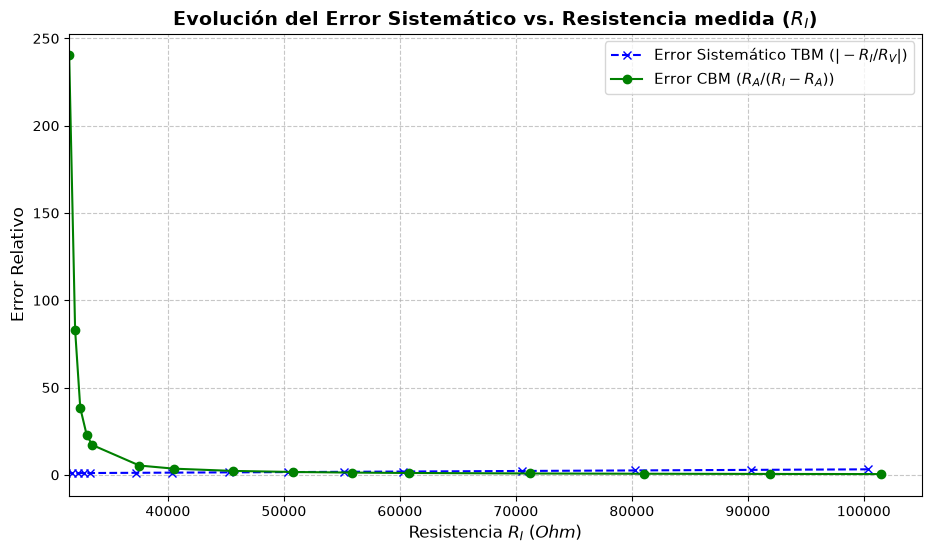

In [31]:
calcular_resistencia = lambda d: [a / (b * (10**-6)) for a, b in zip(d['Tension_V'], d['Corriente_uA'])]
R_A=R_V=31622.0
datos_cbm = {
    "Tension_V": [
        1.1587,
        1.1636,
        1.1674,
        1.1681,
        1.171,
        1.1689,
        1.1688,
        1.1688,
        1.1685,
        1.1685,
        1.1683,
        1.1681,
        1.1681,
        1.168,
        1.1679,
        1.1678,
        1.1676,
        1.1676,
        1.1676,
        1.1675,
        1.1675,
        1.1675,
        1.1675,
        1.1675,
        1.1674    
	],
    "Corriente_uA": [
        1915,
        1051,
        374,
        227.4,
        114.7,
        76.7,
        55.5,
        46.1,
        42.7,
        38.4,
        37.1,
        36.5,
        36,
        35.4,
        34.9,
        31.1,
        28.8,
        25.6,
        23,
        20.9,
        19.2,
        16.4,
        14.4,
        12.7,
        11.5
    ]
}
datos_cbm['Resistencia_Ind'] = calcular_resistencia(datos_cbm)

datos_tbm = {
    "Tension_V": [
        0.9951,
        1.0573,
        1.1277,
        1.1428,
        1.1545,
        1.1583,
        1.1603,
        1.1613,
        1.1617,
        1.1621,
        1.1622,
        1.1622,
        1.1623,
        1.1623,
        1.1624,
        1.1627,
        1.1629,
        1.1632,
        1.1635,
        1.1636,
        1.1637,
        1.164,
        1.1641,
        1.1643,
        1.1645
    ],
    "Corriente_uA": [
        1655,
        1054,
        375,
        227.3,
        114.4,
        76.6,
        57.5,
        46.1,
        42.7,
        38.4,
        37.2,
        36.6,
        36,
        35.5,
        34.9,
        31.2,
        28.8,
        25.7,
        23.1,
        21.1,
        19.3,
        16.5,
        14.5,
        12.9,
        11.6,
    ],
}
datos_tbm['Resistencia_Ind'] = calcular_resistencia(datos_tbm)



df_cbm = pd.DataFrame(datos_cbm)
df_tbm = pd.DataFrame(datos_tbm)

df_tbm["Error_Rel"] = abs(-df_tbm["Resistencia_Ind"] / R_V)
df_cbm["Error_Rel"] = abs(R_A / (df_cbm["Resistencia_Ind"] - R_A))

# 4. Configuración del Gráfico de Errores vs R_I
plt.figure(figsize=(11, 6))

# Ploteo de Error TBM
plt.plot(
    df_tbm["Resistencia_Ind"],
    df_tbm["Error_Rel"],
    marker="x",
    linestyle="--",
    color="blue",
    linewidth=1.5,
    label="Error Sistemático TBM ($|-R_I / R_V|$)",
)

# Ploteo de Error CBM
plt.plot(
    df_cbm["Resistencia_Ind"],
    df_cbm["Error_Rel"],
    marker="o",
    linestyle="-",
    color="green",
    linewidth=1.5,
    label="Error CBM ($R_A / (R_I - R_A)$)",
)

# Configuración de ejes y títulos
plt.title(
    "Evolución del Error de Método vs. Resistencia medida ($R_I$)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Resistencia $R_I$ ($Ohm$)", fontsize=12)
plt.ylabel("Error Relativo", fontsize=12)
plt.xlim(31500, 105000)
# Añadir rejilla y la leyenda para identificar las curvas
plt.grid(True, which="both", linestyle="--", alpha=0.7)
plt.legend(fontsize=11)

# Mostrar resultado
plt.show()


# Conclusiones
Analizando la tabla de resultados, comprobamos empíricamente que:

1. **Para resistencias de valor bajo (10 Ω):** El método recomendado es el **TBM**. En el método CBM, la resistencia interna del amperímetro (100 Ω) resulta ser un valor significativo que se suma a la medición de $R_x$, por lo cual la tensión leída por el voltímetro arrastra un error de método muy grande que distorsiona el valor final.

2. **Para resistencias de valor alto (1 MΩ):** El método recomendado es el **CBM**. En el método TBM, la resistencia interna del voltímetro (10 MΩ) ya no puede considerarse "infinita" en comparación a $R_x$. Por ende, parte considerable de la corriente derivada es leída por el amperímetro, falseando el valor medido final.

3. **Para resistencias de valor intermedio (10 kΩ):** Ambos métodos presentan un error de método similar. El valor ideal de transición donde el error de método para ambas configuraciones se iguala está dado por la fórmula de la "Resistencia Crítica" ( $R_C = \sqrt{R_v R_a}$ ). Sabiendo que $R_v = 10 \text{ M}\Omega$ y $R_a = 100 \text{ }\Omega$, obtenemos que $R_C = 31.62 \text{ k}\Omega$.